# Level 1: Time Series EDA & Signal Quality
**Author:** Teerapord Lin  
**Objective:** Exploratory Data Analysis on HST signals to assess data quality and build a clean dataset.

This notebook performs:
1. EDF extraction and signal loading.
2. Sentinel value and missing data handling.
3. Signal Quality Index (SQI) calculation.
4. Multi-channel time-series visualization.
5. Signal correlation analysis.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import edfio

plt.style.use('seaborn-v0_8-whitegrid')


## 1. Load Data from EDF

In [ ]:
# Path to the raw data
edf_path = "../../data/raw/patient_001/recording.edf"
print(f"Loading {edf_path}...")

# Read EDF file
edf = edfio.read_edf(edf_path)

# Show signals and their sampling frequencies
print("\nChannels in EDF:")
for idx, sig in enumerate(edf.signals):
    print(f"CH{idx}: {sig.label} - {sig.sampling_frequency} Hz - {len(sig.data)} samples")


Loading ../../data/raw/patient_001/recording.edf...

Channels in EDF:
CH0: Resp nasal - 100.0 Hz - 2359000 samples
CH1: Resp thorax - 10.0 Hz - 235900 samples
CH2: Pulse - 1.0 Hz - 23590 samples
CH3: SaO2 - 1.0 Hz - 23590 samples
CH4: Battery - 1.0 Hz - 23590 samples
CH5: Position - 1.0 Hz - 23590 samples
CH6: Acc x-axis - 10.0 Hz - 235900 samples
CH7: Acc y-axis - 10.0 Hz - 235900 samples
CH8: Acc z-axis - 10.0 Hz - 235900 samples


## 2. Process and Resample Signals
We will align all channels to a common frequency of 10 Hz for our clean dataframe.


In [ ]:
target_freq = 10  # 10 Hz
print(f"\nResampling all channels to {target_freq} Hz...")

signal_dict = {}
duration = len(edf.signals[0].data) / edf.signals[0].sampling_frequency
target_length = int(duration * target_freq)
target_time = np.linspace(0, duration, target_length, endpoint=False)

for sig in edf.signals:
    label = sig.label.strip()
    fs = sig.sampling_frequency
    
    # Original time axis for this signal
    orig_time = np.linspace(0, duration, len(sig.data), endpoint=False)
    
    # Interpolate to target frequency
    # We use numpy's interp for fast linear interpolation
    resampled_data = np.interp(target_time, orig_time, sig.data)
    signal_dict[label] = resampled_data

# Create DataFrame
time_idx = pd.to_timedelta(target_time, unit='s')
df = pd.DataFrame(signal_dict, index=time_idx)

# Clean column names
df.columns = [c.replace(' ', '_') for c in df.columns]
print("DataFrame Shape:", df.shape)
df.head()



Resampling all channels to 10 Hz...
DataFrame Shape: (235900, 9)


,Resp_nasal,Resp_thorax,Pulse,SaO2,Battery,Position,Acc_x-axis,Acc_y-axis,Acc_z-axis
0 days 00:00:00,11.635004,41.750210,511.0,127.0,3122.0,9.0,-1.090196,0.164706,0.164706
0 days 00:00:00.100000,10.319677,38.759442,511.0,127.0,3122.0,9.0,-1.168627,0.211765,0.007843
0 days 00:00:00.200000,12.919814,34.532692,511.0,127.0,3122.0,9.0,-1.168627,0.164706,-0.180392
0 days 00:00:00.300000,14.888228,26.475929,511.0,127.0,3122.0,9.0,-1.152941,0.117647,-0.196078
0 days 00:00:00.400000,16.105898,20.692760,511.0,127.0,3122.0,9.0,-1.074510,0.023529,-0.086275


## 3. Handle Sentinel Values
- **Pulse:** 511
- **SaO2:** 127
We replace these with `NaN` before analysis.


In [ ]:
# Find actual column names
pulse_col = [c for c in df.columns if 'Pulse' in c][0]
sao2_col = [c for c in df.columns if 'SaO2' in c or 'SpO2' in c][0]

# Count sentinels
pulse_sentinels = (df[pulse_col] == 511).sum()
sao2_sentinels = (df[sao2_col] == 127).sum()

print(f"Found {pulse_sentinels} sentinel values (511) in {pulse_col}")
print(f"Found {sao2_sentinels} sentinel values (127) in {sao2_col}")

# Replace with NaN
df.loc[df[pulse_col] == 511, pulse_col] = np.nan
df.loc[df[sao2_col] == 127, sao2_col] = np.nan

print("Sentinel values replaced with NaN.")


Found 9986 sentinel values (511) in Pulse
Found 9806 sentinel values (127) in SaO2
Sentinel values replaced with NaN.


## 4. Signal Quality Index (SQI)
Calculate the proportion of valid (non-NaN) data time for each channel.


In [ ]:
total_samples = len(df)
sqi_report = {}

for col in df.columns:
    valid_samples = df[col].notna().sum()
    sqi = (valid_samples / total_samples) * 100
    sqi_report[col] = sqi
    print(f"SQI for {col}: {sqi:.2f}% valid data")

# Overall data validity (all essential channels present)
essential_cols = [c for c in df.columns if 'Resp' in c or 'Pulse' in c or 'SaO2' in c]
valid_all = df[essential_cols].notna().all(axis=1).sum()
overall_sqi = (valid_all / total_samples) * 100
print(f"\nOverall SQI (all essential channels valid): {overall_sqi:.2f}%")


SQI for Resp_nasal: 100.00% valid data
SQI for Resp_thorax: 100.00% valid data
SQI for Pulse: 95.77% valid data
SQI for SaO2: 95.84% valid data
SQI for Battery: 100.00% valid data
SQI for Position: 100.00% valid data
SQI for Acc_x-axis: 100.00% valid data
SQI for Acc_y-axis: 100.00% valid data
SQI for Acc_z-axis: 100.00% valid data

Overall SQI (all essential channels valid): 95.70%


## 5. Save Clean Dataset
We will save the aligned, cleaned data to a Parquet file for Level 2 & 3.


In [ ]:
# Save to outputs
out_path = "outputs/clean_data.parquet"
df.to_parquet(out_path)
print(f"Clean dataset saved to {out_path} ({os.path.getsize(out_path)/1024/1024:.2f} MB)")


Clean dataset saved to outputs/clean_data.parquet (3.11 MB)


## 6. Multi-Channel Visualization
Creating a sleep study report overview spanning a 5-minute window.


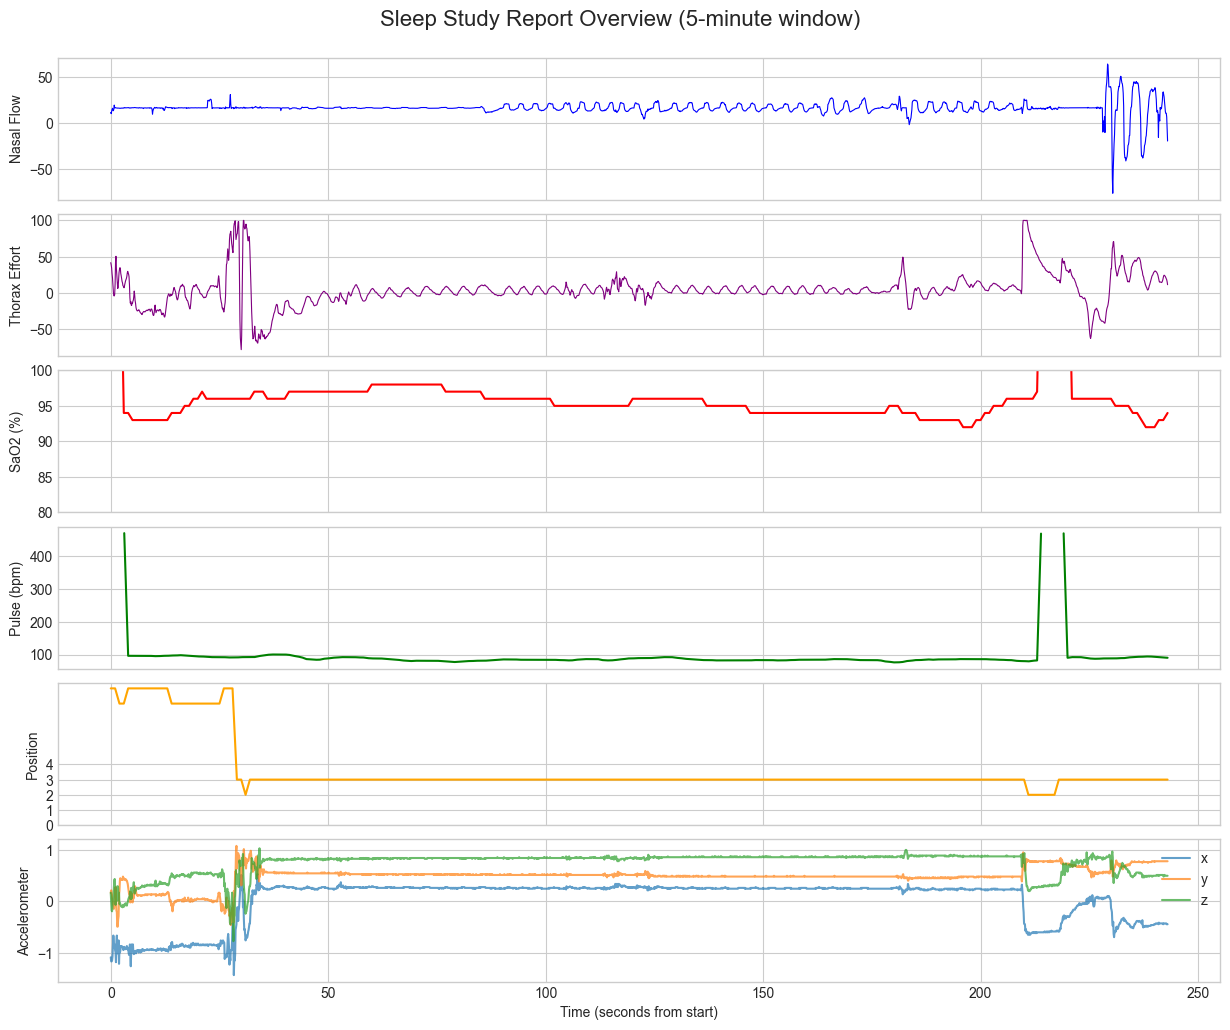

In [ ]:
# Select a 5-minute window with valid events
# Assuming apnea events might be visible where SpO2 drops
# Let's find an interesting segment where SpO2 < 95%
interesting_idx = df[(df[sao2_col] < 95) & (df[sao2_col] > 80)].index
if len(interesting_idx) > 0:
    start_time = interesting_idx[0] - pd.Timedelta(minutes=1)
else:
    start_time = df.index[len(df)//2]  # Just take the middle
    
end_time = start_time + pd.Timedelta(minutes=5)
df_plot = df.loc[start_time:end_time]

fig, axes = plt.subplots(6, 1, figsize=(15, 12), sharex=True, gridspec_kw={'hspace': 0.1})

# Flow
axes[0].plot(df_plot.index.total_seconds(), df_plot['Resp_nasal'], color='blue', linewidth=0.8)
axes[0].set_ylabel('Nasal Flow')

# Thorax Effort
axes[1].plot(df_plot.index.total_seconds(), df_plot['Resp_thorax'], color='purple', linewidth=0.8)
axes[1].set_ylabel('Thorax Effort')

# SpO2
axes[2].plot(df_plot.index.total_seconds(), df_plot[sao2_col], color='red')
axes[2].set_ylabel('SaO2 (%)')
axes[2].set_ylim(80, 100)

# Pulse
axes[3].plot(df_plot.index.total_seconds(), df_plot[pulse_col], color='green')
axes[3].set_ylabel('Pulse (bpm)')

# Position
axes[4].plot(df_plot.index.total_seconds(), df_plot['Position'], color='orange')
axes[4].set_ylabel('Position')
axes[4].set_yticks([0,1,2,3,4])

# Accel
axes[5].plot(df_plot.index.total_seconds(), df_plot['Acc_x-axis'], label='x', alpha=0.7)
axes[5].plot(df_plot.index.total_seconds(), df_plot['Acc_y-axis'], label='y', alpha=0.7)
axes[5].plot(df_plot.index.total_seconds(), df_plot['Acc_z-axis'], label='z', alpha=0.7)
axes[5].set_ylabel('Accelerometer')
axes[5].legend(loc='upper right')
axes[5].set_xlabel('Time (seconds from start)')

plt.suptitle('Sleep Study Report Overview (5-minute window)', y=0.92, fontsize=16)
plt.savefig('outputs/events_timeline.png', bbox_inches='tight')
plt.show()


## 7. Correlation Analysis
Analyzing the relationship between Flow reduction and SpO2. We apply a rolling window to see if drops in flow correlate with drops in SpO2.


Correlation between Flow Variance and SaO2 (20s later): -0.009


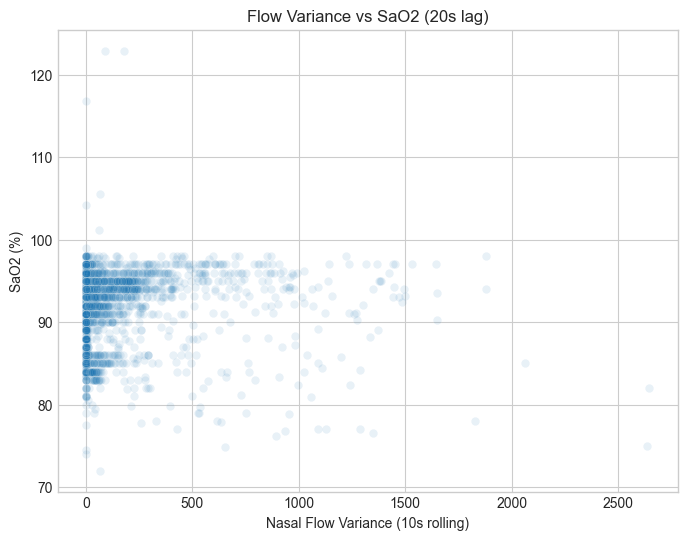

In [ ]:
# Rolling variance of flow (proxy for flow reduction/apnea)
rolling_flow_var = df['Resp_nasal'].rolling(window=100).var() # 10s window

# Drop NaNs for correlation
corr_df = pd.DataFrame({
    'Flow_Variance': rolling_flow_var,
    'SaO2': df[sao2_col]
}).dropna()

# Correlation (usually there's a lag of 10-30s between flow drop and SpO2 drop)
# Let's shift SaO2 backwards by 20 seconds (200 samples at 10Hz)
corr_df['SaO2_shifted'] = corr_df['SaO2'].shift(-200)

corr = corr_df[['Flow_Variance', 'SaO2_shifted']].corr().iloc[0,1]
print(f"Correlation between Flow Variance and SaO2 (20s later): {corr:.3f}")

plt.figure(figsize=(8,6))
sns.scatterplot(x=corr_df['Flow_Variance'][::100], y=corr_df['SaO2_shifted'][::100], alpha=0.1)
plt.title('Flow Variance vs SaO2 (20s lag)')
plt.xlabel('Nasal Flow Variance (10s rolling)')
plt.ylabel('SaO2 (%)')
plt.show()
